In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.columns

Index(['id', 'encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide.metformin', 'glipizide.metformin',
       'glimepiride.pioglitazone', 'metformin.rosiglitazone',
       'metformin.pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [4]:
df.head(3)

,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,...,No,No,No,No,No,No,No,No,No,NO
1,2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO


In [5]:
df['readmitted'].unique()

<StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str

In [6]:
""" <30 -> patient was readmitted within 30 days of being discharged from the hospital
most critical (often hospital are penalized if this happens)

>30 -> patient was readmitted after 30 days of being discharged from the hospital
important but less severe

No -> patient was not readmitted to the hospital after being discharged
majority class in this dataset """

' <30 -> patient was readmitted within 30 days of being discharged from the hospital\nmost critical (often hospital are penalized if this happens)\n\n>30 -> patient was readmitted after 30 days of being discharged from the hospital\nimportant but less severe\n\nNo -> patient was not readmitted to the hospital after being discharged\nmajority class in this dataset '

In [7]:
def plot_class_distribution(y_old, y_new, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(title, fontsize=16)

    sns.countplot(x=y_old, ax=ax1)
    ax1.set_title("Original Distribution")
    ax1.set_xlabel("Readmission Category")
    ax1.set_ylabel("Count")
    ax1.set_xticklabels(ticks=[0,1], labels=['NO / >30 days', '<30days'])

    sns.countplot(x=y_new, ax=ax2)
    ax2.set_title("Resampled Distribution")
    ax2.set_xlabel("Readmission Category")
    ax2.set_ylabel("Count")
    ax2.set_xticklabels(ticks=[0,1], labels=['NO / >30 days', '<30days'])

    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

In [8]:
# Drop ID like columns

X = df.drop(columns=['encounter_id', 'patient_nbr', 'readmitted', 'id'], errors='ignore')
y = df['readmitted']

In [9]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      101766 non-null  str  
 1   gender                    101766 non-null  str  
 2   age                       101766 non-null  str  
 3   weight                    101766 non-null  str  
 4   admission_type_id         101766 non-null  int64
 5   discharge_disposition_id  101766 non-null  int64
 6   admission_source_id       101766 non-null  int64
 7   time_in_hospital          101766 non-null  int64
 8   payer_code                101766 non-null  str  
 9   medical_specialty         101766 non-null  str  
 10  num_lab_procedures        101766 non-null  int64
 11  num_procedures            101766 non-null  int64
 12  num_medications           101766 non-null  int64
 13  number_outpatient         101766 non-null  int64
 14  number_emergency          10176

In [10]:
# Convert categorical to numeric (for SMOTE/ADASYN)
X = pd.get_dummies(X)


In [11]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

In [12]:
# 1. Random Under-Sampling

rus = RandomUnderSampler(sampling_strategy='not majority', random_state=1)
rus_majority = RandomUnderSampler(sampling_strategy='majority', random_state=1)
rus_all = RandomUnderSampler(sampling_strategy='all', random_state=1)


In [13]:
X_rus, y_rus = rus.fit_resample(X, y)

In [14]:
X_rus_maj, y_rus_maj = rus_majority.fit_resample(X, y)
X_rus_all, y_rus_all = rus_all.fit_resample(X, y)

In [15]:
from collections import Counter

In [16]:
print("Original Distribution:", Counter(y))


Original Distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})


In [17]:
print("Under Sampling (not majority) Distribution:", Counter(y_rus))
print("Under Sampling (majority) Distribution:", Counter(y_rus_maj))
print("Under Sampling (all) Distribution:", Counter(y_rus_all))

Under Sampling (not majority) Distribution: Counter({'NO': 54864, '<30': 11357, '>30': 11357})
Under Sampling (majority) Distribution: Counter({'>30': 35545, '<30': 11357, 'NO': 11357})
Under Sampling (all) Distribution: Counter({'<30': 11357, '>30': 11357, 'NO': 11357})


In [18]:
def plot_class_distribution_4(y1, y2, y3, y4, title):
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 8))
    fig.suptitle(title, fontsize=16)

    sns.countplot(x=y1, ax=ax1)
    ax1.set_title("Original Distribution")
    ax1.set_xlabel("Readmission Category")
    ax1.set_ylabel("Count")
    ax1.set_xticks(ticks=[0,1,2], labels=['NO', '>30 days', '<30days'])

    sns.countplot(x=y2, ax=ax2)
    ax2.set_title("Resampled Distribution (not majority)")
    ax2.set_xlabel("Readmission Category")
    ax2.set_ylabel("Count")
    ax2.set_xticks(ticks=[0,1,2], labels=['NO', '>30 days', '<30days'])

    sns.countplot(x=y3, ax=ax3)
    ax3.set_title("Resampled Distribution (majority)")
    ax3.set_xlabel("Readmission Category")
    ax3.set_ylabel("Count")
    ax3.set_xticks(ticks=[0,1,2], labels=['NO', '>30 days', '<30days'])

    sns.countplot(x=y4, ax=ax4)
    ax4.set_title("Resampled Distribution (all)")
    ax4.set_xlabel("Readmission Category")
    ax4.set_ylabel("Count")
    ax4.set_xticks(ticks=[0,1,2], labels=['NO', '>30 days', '<30days'])

    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

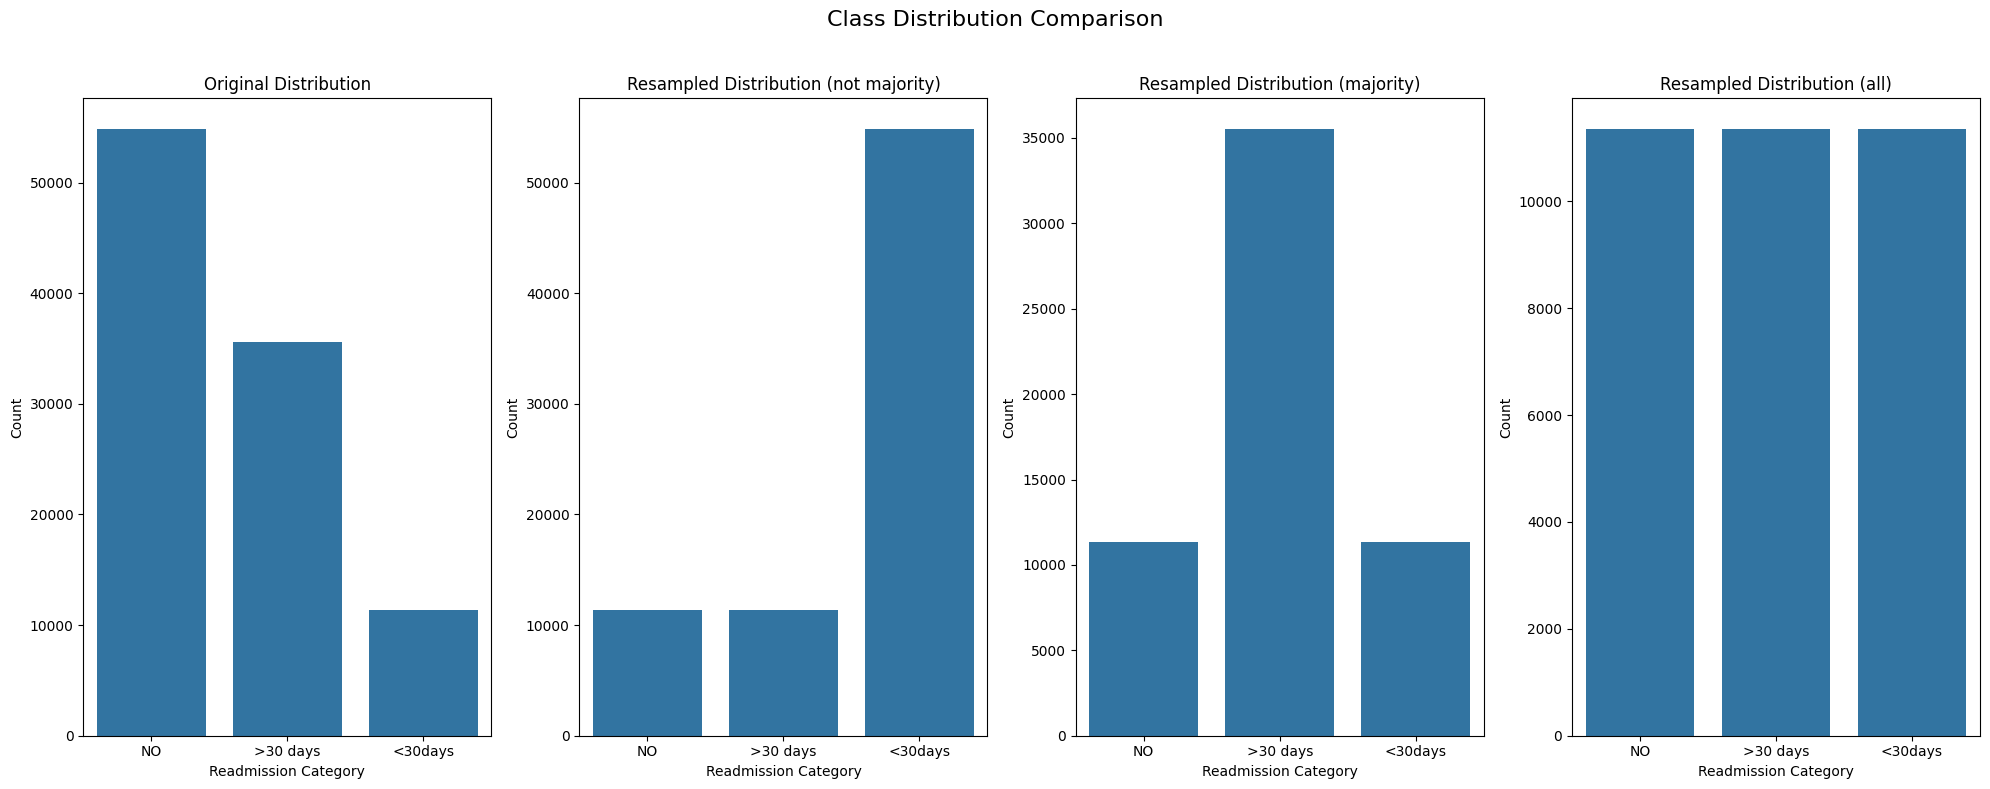

In [19]:
plot_class_distribution_4(y, y_rus, y_rus_maj, y_rus_all, "Class Distribution Comparison")

In [20]:
# Random Over Sampling

ros = RandomOverSampler(sampling_strategy='not majority', random_state=1)
X_ros, y_ros = ros.fit_resample(X, y)
print("Originial Distribution:", Counter(y))
print("Over Sampling (not majority) Distribution:", Counter(y_ros))

Originial Distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
Over Sampling (not majority) Distribution: Counter({'NO': 54864, '>30': 54864, '<30': 54864})


In [ ]:
# SMOTE
smote = SMOTE(sampling_strategy='not majority', random_state=1)
X_smote, y_smote = smote.fit_resample(X, y)
print("Original Distribution:", Counter(y))
print("SMOTE (not majority) Distribution:", Counter(y_smote))

In [ ]:
# ADASYN
adasyn = ADASYN(sampling_strategy='not majority', random_state=1)
X_adasyn, y_adasyn = adasyn.fit_resample(X, y)
print("Original Distribution:", Counter(y))
print("ADASYN (not majority) Distribution:", Counter(y_adasyn))

In [ ]:
# ADASYN
adasyn = ADASYN(sampling_strategy='auto', random_state=1)
X_adasyn, y_adasyn = adasyn.fit_resample(X, y)
print("Original Distribution:", Counter(y))
print("ADASYN (not majority) Distribution:", Counter(y_adasyn))